<a href="https://colab.research.google.com/github/scudilio/FACENS/blob/main/Aula_3_Facen_Machine_Learning_Classificacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aula 3 - Machine Learning Supervisionado

Objetivo: desenvolver um modelo de ML para classificar clientes que vao dar default ou nao na minha empresa

# 1. Organizar Setup e Coletar os Dados

In [ ]:
pip install pandas #instalando a biblioteca pandas processamento de dados

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split #metodo validar se a maquina aprendeu ou decorou
from sklearn.tree import DecisionTreeClassifier #algoritmo de arvore, outras opcoes lgbm, xgboost, reg.logistica
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report #metodo para avaliar o quanto meu algoritmo aprendeu

In [194]:
url = 'https://raw.githubusercontent.com/scudilio/Churn_model/refs/heads/master/dataset/Churn_Modelling.csv'

In [223]:
df = pd.read_csv(url)

In [222]:
df1 = df.copy()

In [197]:
df.head(8)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1


# 2. Entendimento dos dados

- dados faltantes
- dados outliers
- relacoes fortes entre as features
- target eh desbalenceada

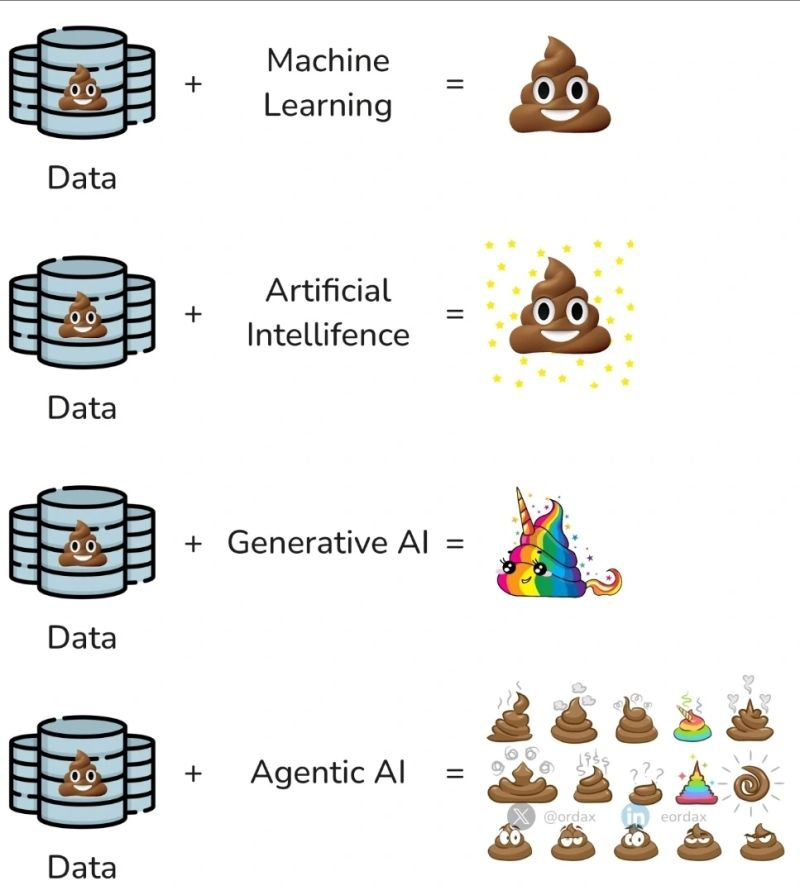

In [199]:
#dados faltantes

df.isnull().sum()
## knn imputer sklearn faz tratamento missing

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [200]:
# tamanho do data frame

df.shape
# 10 mil linhas e 14 colunas

(10000, 14)

In [201]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [202]:
## Analise descritiva da base de dados
# objetivo: identificar possiveis outliers, dados incosistentes e analisar as caracteristicas dos clientes
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [203]:
#proporcao de 1 da target
df['Exited'].mean()

np.float64(0.2037)

In [204]:
#mulheres tem mais propensao a cancelar a conta corrente
df.groupby('Gender')['Exited'].mean()

,Exited
Gender,
Female,0.250715
Male,0.164559


In [205]:
# algum pais tem mais propensao em cancelar a CC
df.groupby('Geography')['Exited'].mean()

,Exited
Geography,
France,0.161548
Germany,0.324432
Spain,0.166734


In [206]:
df.groupby('Exited')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


## **3. Pre-processamento**

- tratar dados faltantes  (completar dados numericos pela media/media, dados categoricos pela moda ou usar knn imputer)
- transformar string em numeros (label encoding ou one hot enconder)
- tirar o vies de escala (padronizar os dados)
- Reduzir o numeros colunas eliminado features desnecessarias (drop colunas ou usar tecnicas de ML para reduzir dimensao)

In [207]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

### a. Reduzindo Dimensao

Excluir colunas que nao serao utilizadas no modelo

In [224]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [209]:
df.head(1)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.0,1,1,1,101348.88,1


## Validacao separar em treino e teste

🔒 Data Leakage

Para evitar vazamento de dados (data leakage) — ou seja, que informações do conjunto de teste influenciem o processo de treinamento — é fundamental realizar a separação entre treino e teste antes de qualquer transformação nos dados.

Etapas como:

Normalização ou padronização de variáveis numéricas

One-Hot Encoding (aqui nao tem problema)

Imputação de valores faltantes

Seleção de variáveis

devem ser ajustadas (fit) exclusivamente com os dados de treino e, posteriormente, aplicadas (transform) ao conjunto de teste.

Se essas transformações forem feitas antes da divisão da amostra, estatísticas do conjunto de teste (como média e desvio padrão) acabam sendo incorporadas ao modelo durante o treinamento, comprometendo a validade da avaliação e gerando métricas artificialmente otimistas.

Portanto, a ordem correta do processo é:

Dividir os dados em treino e teste

Ajustar as transformações utilizando apenas o treino

Aplicar as transformações ao teste

Treinar o modelo

Avaliar no conjunto de teste

Essa prática garante uma avaliação mais realista e evita contaminação do modelo.

In [225]:
# modelos supervisionados tenho uma target e features, entao vou definir o que eh resposta o que eh informacao (features)
X = df.drop('Exited', axis=1)
y = df['Exited']

In [226]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


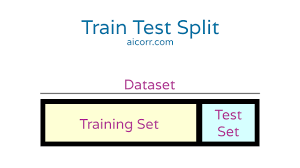

In [227]:
# validacao hold out ou treino test e split - metodo para validar se o modelo aprendeu
x_treino, x_teste, y_treino, y_teste = train_test_split(X,y, test_size=0.30, random_state =34)

### **b. Transformar Categorias em Numeros**

In [228]:
from sklearn.preprocessing import LabelEncoder # ordena por alfabetica e transforma em numeros usada para variaveis categoricas ordinais (com ordem)
from sklearn.preprocessing import OneHotEncoder # cria variaveis dummys (binarias) , utilizada para quando temos variaveis categoricas nominais (sem ordem)

In [229]:
lb = LabelEncoder()

x_treino['Gender'] = lb.fit_transform(x_treino['Gender'])
x_teste['Gender'] = lb.transform(x_teste['Gender'])

In [245]:
x_treino.tail(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
5667,672,France,0,34,8,0.0,2,1,1,16245.25
324,734,France,1,30,3,0.0,2,1,0,107640.25
3157,574,Spain,1,34,5,0.0,2,0,0,28269.86
5993,597,France,1,45,7,0.0,2,0,0,167756.45
5242,655,Germany,0,40,0,81954.6,1,1,1,198798.44


In [231]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [239]:
encoder.fit_transform(x_treino[['Geography']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7000 stored elements and shape (7000, 3)>

In [240]:
encoder.get_feature_names_out()

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [243]:
encoder.transform(x_teste[['Geography']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3000 stored elements and shape (3000, 3)>

In [247]:
# one hot encoder utilizada para dados nominais, categorias sem ordem, objetivo cada classe vira uma coluna
# one hot encoder utilizada para dados nominais
encoder = OneHotEncoder()

geo_encoded_treino = encoder.fit_transform(x_treino[['Geography']]).toarray()
geo_encoded_teste = encoder.transform(x_teste[['Geography']]).toarray()

geo_cols = encoder.get_feature_names_out()

geo_treino = pd.DataFrame(geo_encoded_treino, columns=geo_cols, index=x_treino.index)
geo_teste = pd.DataFrame(geo_encoded_teste, columns=geo_cols, index=x_teste.index)

In [248]:
x_treino = pd.concat([x_treino.drop('Geography', axis=1), geo_treino], axis=1)
x_teste = pd.concat([x_teste.drop('Geography', axis=1), geo_teste], axis=1)

In [250]:
x_treino.head(1)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
3525,625,1,31,4,77743.01,2,1,0,75335.68,0.0,1.0,0.0


In [117]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,gender,Geography_France,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,1.0,0.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0.0,0.0,1.0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,1.0,0.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,0,1.0,0.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0.0,0.0,1.0


#3 Tratando variaveis numericas - Standard Scale

In [251]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
standard = StandardScaler() # transformar os dados na distribuicao normal padrao, dados ficam entre -3 e 3
minmax = MinMaxScaler() # transforma os dados entre -1 e 1

In [252]:
x_treino[['CreditScore', 'Age', 'Tenure',
                       'Balance', 'NumOfProducts',
                       'EstimatedSalary']].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,649.928286,38.815857,5.026143,76246.783724,1.525571,99394.545850
std,96.391742,10.445332,2.894245,62468.890492,0.577155,57523.833113
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,583.000000,32.000000,3.000000,0.000000,1.000000,50214.835000
50%,651.000000,37.000000,5.000000,96953.155000,1.000000,99954.450000
75%,717.250000,44.000000,8.000000,127771.537500,2.000000,148018.875000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [253]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

colunas = ['CreditScore', 'Age', 'Tenure',
           'Balance', 'NumOfProducts',
           'EstimatedSalary']

# 1️⃣ Fit apenas no treino
standard.fit(x_treino[colunas])

# 2️⃣ Transformar treino
x_treino[colunas] = standard.transform(x_treino[colunas])

# 3️⃣ Transformar teste
x_teste[colunas] = standard.transform(x_teste[colunas])

In [254]:
x_treino[colunas].describe()
# note que agora todas as features numericas estao variando de -5 a 5 e desvio padrao igual 1

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,-7.105427e-17,2.182381e-16,-5.278317e-17,-8.425007e-17,-6.191872e-17,-1.654550e-16
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-3.111778e+00,-1.992981e+00,-1.736723e+00,-1.220643e+00,-9.106893e-01,-1.727807e+00
25%,-6.943859e-01,-6.525732e-01,-7.001091e-01,-1.220643e+00,-9.106893e-01,-8.550060e-01
50%,1.111911e-02,-1.738563e-01,-9.033348e-03,3.314906e-01,-9.106893e-01,9.734124e-03
75%,6.984678e-01,4.963474e-01,1.027580e+00,8.248655e-01,8.220710e-01,8.453505e-01
max,2.075759e+00,5.092030e+00,1.718656e+00,2.796012e+00,4.287592e+00,1.748929e+00


In [255]:
x_teste.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
2390,-0.497260,1,-0.652573,0.682042,1.736494,0.822071,1,0,0.250131,0.0,1.0,0.0
6803,-0.850012,0,0.496347,0.682042,-1.220643,0.822071,0,0,-0.643673,1.0,0.0,0.0
3226,-0.486884,1,-0.365343,-1.391185,0.465853,0.822071,1,1,0.538684,0.0,1.0,0.0
8630,0.581748,0,0.496347,-1.045647,1.755966,0.822071,1,0,-0.590774,0.0,1.0,0.0
4898,-1.099014,0,0.113374,0.682042,-1.220643,-0.910689,0,1,1.072369,1.0,0.0,0.0


## **4. Modelagem**

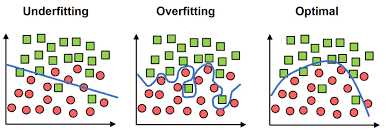

## Evitando o overfitting na arvore de decisao
*  para evitar overfitting precisamos dar criterios de parada para a arvore, senao ela aprende de mais

um criteiro para isso eh definir o maximo de profundidade da arvore (max_depth)

In [256]:
#arquitetura da arvore de decisao
tree = DecisionTreeClassifier(max_depth= 6, min_samples_split= 20)

In [257]:
## fit eh o treinamento da arvore, momento que o algoritmo aprende o padrao dos dados para dar a resposta
tree.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=6, min_samples_split=20)

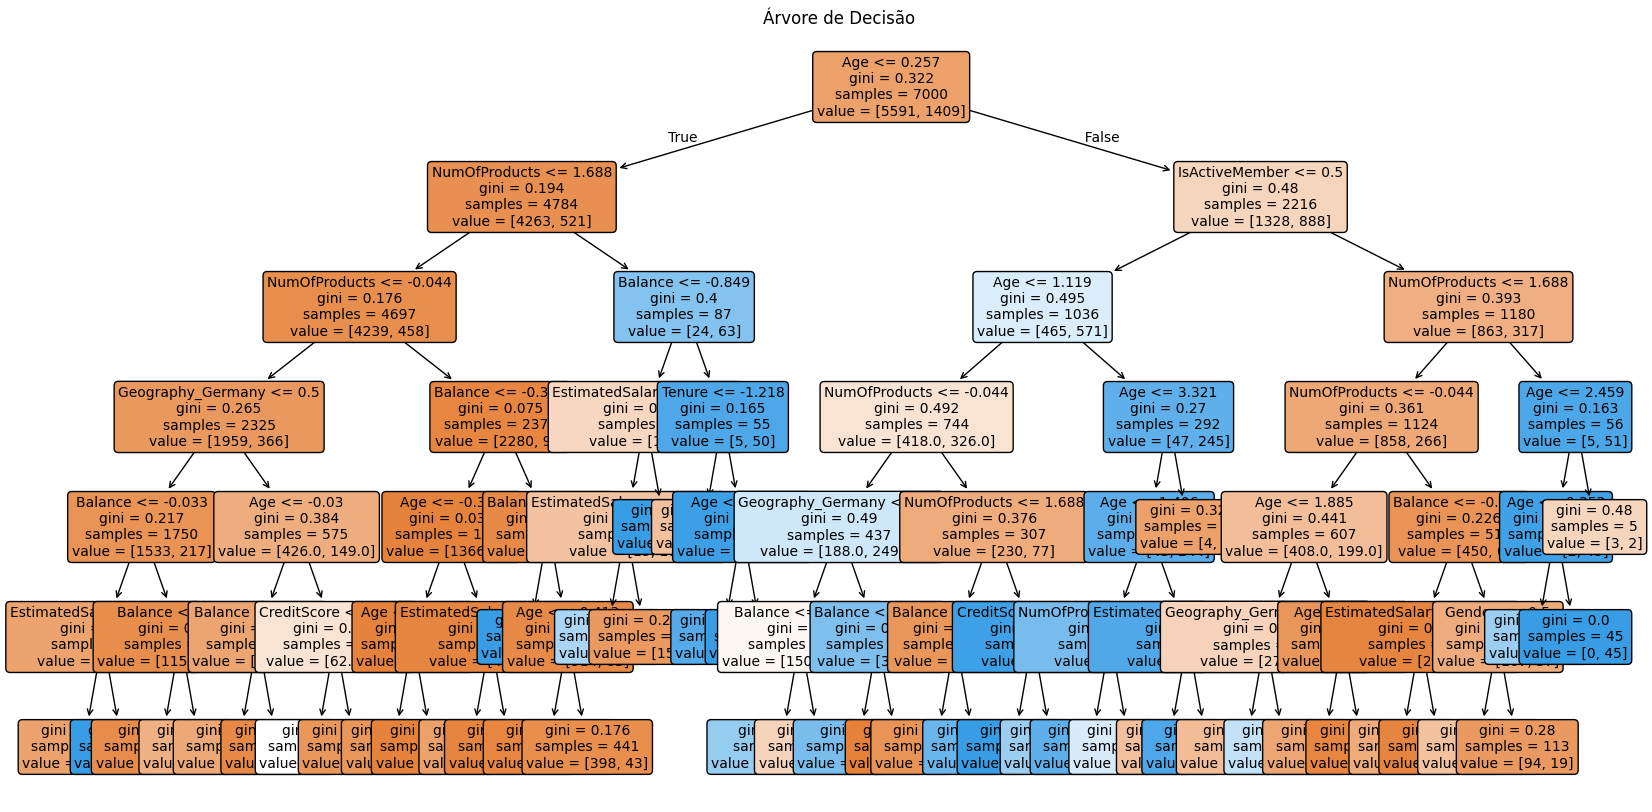

In [258]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=x_treino.columns,
    filled=True,          # colore os nós
    rounded=True,         # deixa cantos arredondados
    fontsize=10
)

plt.title("Árvore de Decisão")
plt.show()

In [259]:
importancias = pd.Series(
    tree.feature_importances_,
    index=x_treino.columns
).sort_values(ascending=False)

importancias

,0
Age,0.432767
NumOfProducts,0.307037
IsActiveMember,0.104540
Balance,0.077785
Geography_Germany,0.049158
EstimatedSalary,0.013888
CreditScore,0.005491
Tenure,0.005301
Gender,0.004034
HasCrCard,0.000000


A arvore serve para fazer selecao de variaveis, no caso acima observamos que hascrcard e france/spain tem importancia zero, ou seja, nao eh significativo para prever o churn dos clientes

## Avaliacao de modelos de Classificacao

## Avaliar os resultados do modelo

* o modelo aprendeu se nos dados de treino foi possivel ter boas previsoes ( analisando o underfitting)

* para analisar se o modelo consegue generalizar seu conhecimento, analiso nos dados de teste se o modelo consegue prever corretamente a classe

* se os resultados do treino e teste forem muitos diferentes, quer dizer que teve overfitting (a maquina aprendeu d+ nos dados treino e nao consegue generalizar para os dados teste)

## A. avaliando se o modelo aprendeu

analiso nos dados de treino

In [260]:
y_pred_treino = tree.predict(x_treino)

In [261]:
confusion_matrix(y_treino, y_pred_treino)

array([[5426,  165],
       [ 769,  640]])

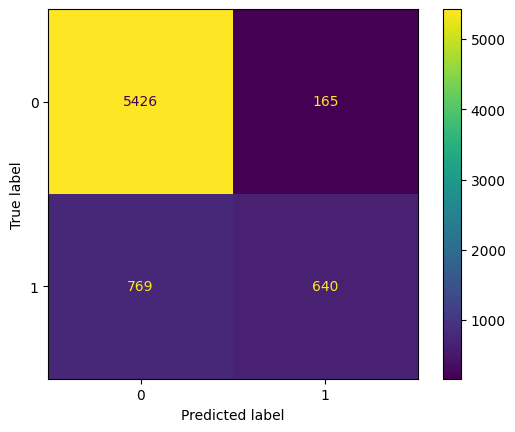

In [262]:
ConfusionMatrixDisplay.from_estimator(tree, x_treino, y_treino)


In [263]:
print(classification_report(y_treino, y_pred_treino))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      5591
           1       0.80      0.45      0.58      1409

    accuracy                           0.87      7000
   macro avg       0.84      0.71      0.75      7000
weighted avg       0.86      0.87      0.85      7000



In [264]:
from sklearn.metrics import classification_report

# Probabilidade da classe 1
y_prob_treino = tree.predict_proba(x_treino)[:,1]

# Novo ponto de corte
threshold = 0.39

# Nova classificação
y_pred_treino = (y_prob_treino >= threshold).astype(int)

# Métricas
print(classification_report(y_treino, y_pred_treino))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      5591
           1       0.70      0.54      0.61      1409

    accuracy                           0.86      7000
   macro avg       0.79      0.74      0.76      7000
weighted avg       0.85      0.86      0.85      7000



In [265]:
confusion_matrix(y_treino, y_pred_treino)

array([[5257,  334],
       [ 642,  767]])

#### Conclusao sobre o aprendizado do modelo

O modelo conseguiu encontrar padroes nos dados e aprender para classificar possiveis clientes churn, ou seja, o modelo nao tem underfitting (ajuste pobre).
considerando um ponte de corte de 0.39, ou seja, se score do modelo for acima de 0.39 classifico o cliente como churn.
Considerando esse ponto de corte, conclui que a precisao do modelo foi de 70% (a cada 100 cliente que indico como churn, 70 serao churn) e recall de 54% (a cada 100 clientes churn, o modelo identificou 54)


## O modelo consegue prever novos clientes

* para isso vou analisar os resultados nos dados de teste, dados esses que sao novos para o modelo ( ele nunca viu), mas nos sabemos a resposta.

In [266]:
y_pred_teste = tree.predict(x_teste)

In [267]:
confusion_matrix(y_teste, y_pred_teste)

array([[2287,   85],
       [ 338,  290]])

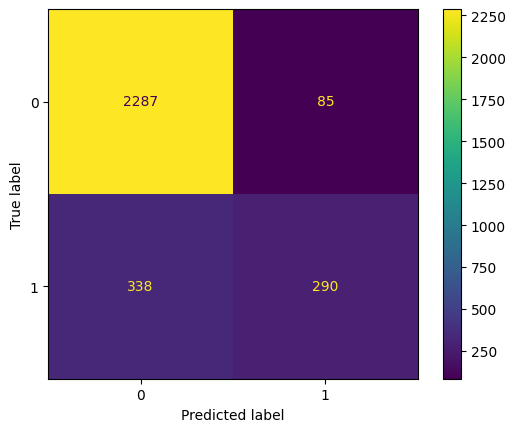

In [268]:
ConfusionMatrixDisplay.from_estimator(tree, x_teste, y_teste)
#

In [269]:
nao_churn = 2290 +82
nao_churn
cap_no_churn = 2290/(2290+82)
cap_no_churn
#

0.9654300168634065

In [270]:
churn = 289 + 339
churn
cap_churn = 289/(289+339)
cap_churn
#

0.4601910828025478

In [304]:
x_treino.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [271]:
print(classification_report(y_teste, y_pred_teste))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      2372
           1       0.77      0.46      0.58       628

    accuracy                           0.86      3000
   macro avg       0.82      0.71      0.75      3000
weighted avg       0.85      0.86      0.84      3000



* com avaliacao das metricas nos dados de teste, concluimos que o modelo consegue generalizar o seu conhecimento, nao temos indicio de overfitting. Porque as metricas nos dados de treino e teste foram parecidas.

In [272]:
from sklearn.metrics import classification_report

# Probabilidade da classe 1
y_prob_teste = tree.predict_proba(x_teste)[:,1]

# Novo ponto de corte
threshold = 0.39

# Nova classificação
y_pred_teste = (y_prob_teste >= threshold).astype(int)

# Métricas
print(classification_report(y_teste, y_pred_teste))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2372
           1       0.69      0.53      0.60       628

    accuracy                           0.85      3000
   macro avg       0.79      0.73      0.75      3000
weighted avg       0.84      0.85      0.84      3000



Conclusao: O modelo serve para prever novos clientes

🔵 **Salvar tudo**

salvamos 3 coisas:

* modelo (salvo o modelo de arvore treinado)

* scaler (tratamento dos dados numericos)

* encoder (tratamento dos dados categoricos)

In [273]:
import joblib

joblib.dump(tree, "modelo_churn_tree.pkl")
joblib.dump(standard, "standard.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(lb, "encoder_gender.pkl")

['encoder_gender.pkl']

## Fazendo novas previsoes para clientes

In [305]:
import joblib
import pandas as pd

def prever_churn(cliente, threshold=0.39):

    modelo = joblib.load("modelo_churn_tree.pkl")
    scaler = joblib.load("standard.pkl")
    encoder_geo = joblib.load("encoder.pkl")

    df = pd.DataFrame([cliente])

    # Gender
    df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

    # OneHot Geography
    geo = encoder_geo.transform(df[['Geography']]).toarray()

    geo_df = pd.DataFrame(
        geo,
        columns=encoder_geo.get_feature_names_out(),
        index=df.index
    )

    df = pd.concat([df.drop('Geography',axis=1), geo_df], axis=1)

    # Escalar numéricas
    cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
    df[cols] = scaler.transform(df[cols])

    # garantir mesma ordem de colunas do treino
    df = df[modelo.feature_names_in_]

    # previsão
    prob = modelo.predict_proba(df)[:,1][0]

    churn = 1 if prob >= threshold else 0

    return {
        "probabilidade_churn": round(prob,4),
        "threshold": threshold,
        "churn": churn
    }

In [306]:
cliente1 = {
'CreditScore':300,
'Geography':'Germany',
'Gender':'Male',
'Age':60,
'Tenure':1,
'Balance':150000,
'NumOfProducts':1,
'HasCrCard':1,
'IsActiveMember':0,
'EstimatedSalary':10000
}

cliente2 = {
'CreditScore':900,
'Geography':'France',
'Gender':'Female',
'Age':25,
'Tenure':5,
'Balance':0,
'NumOfProducts':2,
'HasCrCard':1,
'IsActiveMember':1,
'EstimatedSalary':150000
}

In [308]:
prever_churn(cliente1)

{'probabilidade_churn': np.float64(0.9071), 'threshold': 0.39, 'churn': 1}

In [309]:
prever_churn(cliente2)

{'probabilidade_churn': np.float64(0.0091), 'threshold': 0.39, 'churn': 0}